# Методы регрессии

В этой работе будем сравнивать разные модели регрессии на  датасете
**Brazilian houses to rent**

---


In [1]:
# ============================================================
# Подготовка окружения: импорты и воспроизводимость
# ============================================================

# --- стандартные библиотеки ---
import os
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Функция для фиксации зерна случайности
# ------------------------------------------------------------
def set_seed(seed: int = 111):
    random.seed(seed)
    np.random.seed(seed)


set_seed(111)

print("Окружение готово, seed зафиксирован.")


Окружение готово, seed зафиксирован.


---

## Загрузка датасета Brazilian houses to rent

В этом блоке:

- загрузим регрессионный датасет **Brazilian houses to rent** из коллекции  
  `inria-soda/tabular-benchmark` на Hugging Face;
- приведём его к `pandas.DataFrame`;
- посмотрим форму данных и список признаков.

Датасет: реальные объявления аренды жилья в Бразилии (~10k объектов, ~13 признаков).  
Целевая переменная — размер аренды. 


In [2]:
# ============================================================
# Загрузка датасета Brazilian houses to rent
# ============================================================

from datasets import load_dataset

# Загружаем конфиг регрессии с числовыми фичами
dataset = load_dataset(
    "inria-soda/tabular-benchmark",
    "reg_num_Brazilian_houses",
    cache_dir="./hf_cache"   
)

# В этом бенчмарке обычно один сплит: 'train'
ds_train = dataset["train"]

# В pandas-формат для удобства анализа
df = ds_train.to_pandas()

print("Размер датафрейма (строки, колонки):", df.shape)
print("\nПервые строки:")
df.head()


Размер датафрейма (строки, колонки): (10692, 9)

Первые строки:


,area,rooms,bathroom,parking_spaces,hoa_(BRL),rent_amount_(BRL),property_tax_(BRL),fire_insurance_(BRL),totalBRL
0,70.0,2,1,1,2065.0,3300.0,211.0,42.0,8.633909
1,320.0,4,4,0,1200.0,4960.0,1750.0,63.0,8.983942
2,80.0,1,1,1,1000.0,2800.0,0.0,41.0,8.253748
3,51.0,2,1,0,270.0,1112.0,22.0,17.0,7.259820
4,25.0,1,1,0,0.0,800.0,25.0,11.0,6.729824


---

## Целевая переменная и разбиение на train / val / test

В этом блоке:

- выберем целевую переменную;
- сформируем матрицу признаков;
- разобьём данные на выборки `train`, `val`, `test`.

Целевая переменная: **`rent_amount_(BRL)`** — месячная арендная ставка.  
Колонку **`totalBRL`** из признаков убираем, чтобы не было утечки (она почти напрямую связана с деньгами).


In [3]:
# ============================================================
# Целевая переменная и выбор признаков
# ============================================================

target_col = "rent_amount_(BRL)"

# Убираем целевую и потенциально "слишком информативную" totalBRL
drop_cols = [target_col, "totalBRL"] if "totalBRL" in df.columns else [target_col]

feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df[target_col]

print("Число признаков:", X.shape[1])
print("Список признаков:")
print(feature_cols)


Число признаков: 7
Список признаков:
['area', 'rooms', 'bathroom', 'parking_spaces', 'hoa_(BRL)', 'property_tax_(BRL)', 'fire_insurance_(BRL)']


In [4]:
# ============================================================
# Удаляем дубликаты и пересобираем сплиты
# ============================================================

from sklearn.model_selection import train_test_split

n_before = len(df)
n_duplicates = df.duplicated().sum()

print(f"Размер до удаления дубликатов: {df.shape}")
print(f"Число полностью дублирующихся строк: {n_duplicates}")

df = df.drop_duplicates().reset_index(drop=True)

n_after = len(df)
print(f"Размер после удаления дубликатов: {df.shape}")
print(f"Фактически удалено строк: {n_before - n_after}")

target_col = "rent_amount_(BRL)"

drop_cols = [target_col, "totalBRL"] if "totalBRL" in df.columns else [target_col]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df[target_col]

print("\nЧисло признаков:", X.shape[1])
print("Список признаков:", feature_cols)

# 20% в тест
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=111
)

# Из оставшихся 80% -> 60% train, 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=111
)  # 0.25 * 0.8 = 0.2

print("\nTrain:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)


Размер до удаления дубликатов: (10692, 9)
Число полностью дублирующихся строк: 464
Размер после удаления дубликатов: (10228, 9)
Фактически удалено строк: 464

Число признаков: 7
Список признаков: ['area', 'rooms', 'bathroom', 'parking_spaces', 'hoa_(BRL)', 'property_tax_(BRL)', 'fire_insurance_(BRL)']

Train: (6136, 7) (6136,)
Val:   (2046, 7) (2046,)
Test:  (2046, 7) (2046,)


---

##  Разведочный анализ (EDA): таргет и признаки

В этом блоке:

- посмотрим базовые статистики по признакам и целевой переменной;
- визуализируем распределение таргета (`rent_amount_(BRL)`);
- посмотрим несколько scatter-графиков "признак → аренда".

Никаких моделей пока не строим, просто знакомимся с данными.


In [5]:
# ============================================================
# Базовые статистики по признакам и таргету
# ============================================================

cols_for_stats = feature_cols + [target_col]

df[cols_for_stats].describe().T


,count,mean,std,min,25%,50%,75%,max
area,10228.0,153.285784,548.581635,11.0,60.0,95.0,190.0,46335.0
rooms,10228.0,2.549472,1.166913,1.0,2.0,3.0,3.0,13.0
bathroom,10228.0,2.277278,1.416757,1.0,1.0,2.0,3.0,10.0
parking_spaces,10228.0,1.654576,1.600840,0.0,1.0,1.0,2.0,12.0
hoa_(BRL),10228.0,1097.992569,11504.952531,0.0,180.0,580.0,1300.0,1117000.0
property_tax_(BRL),10228.0,380.019065,3176.762385,0.0,42.0,133.0,395.0,313700.0
fire_insurance_(BRL),10228.0,54.492863,48.291596,3.0,21.0,37.0,70.0,677.0
rent_amount_(BRL),10228.0,3982.498338,3444.931492,450.0,1600.0,2775.0,5000.0,45000.0


По базовым статистикам видно, что все признаки и таргет сильно асимметричны: медиана заметно меньше среднего, а максимумы на порядок превышают 75-й перцентиль, то есть в данных есть немного очень дорогих и/или больших объектов. Для площади и всех денежных признаков (аренда, коммунальные, налог, страховка) наблюдается большой разброс и «толстый» правый хвост, а типичный объект — это жильё средней площади с 2–3 комнатами и 1–2 парковочными местами.

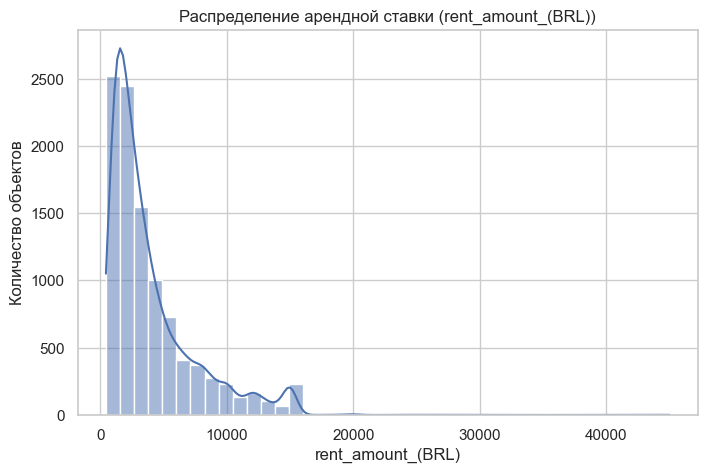

In [6]:
# ============================================================
# Визуализация распределения таргета
# ============================================================

import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.histplot(df[target_col], bins=40, kde=True)
plt.title("Распределение арендной ставки (rent_amount_(BRL))")
plt.xlabel("rent_amount_(BRL)")
plt.ylabel("Количество объектов")
plt.show()


Гистограмма арендной ставки подтверждает сильную правую асимметрию: основная масса объектов сосредоточена в диапазоне до примерно 5–7 тысяч, а дальше виден длинный хвост редких очень дорогих вариантов; 

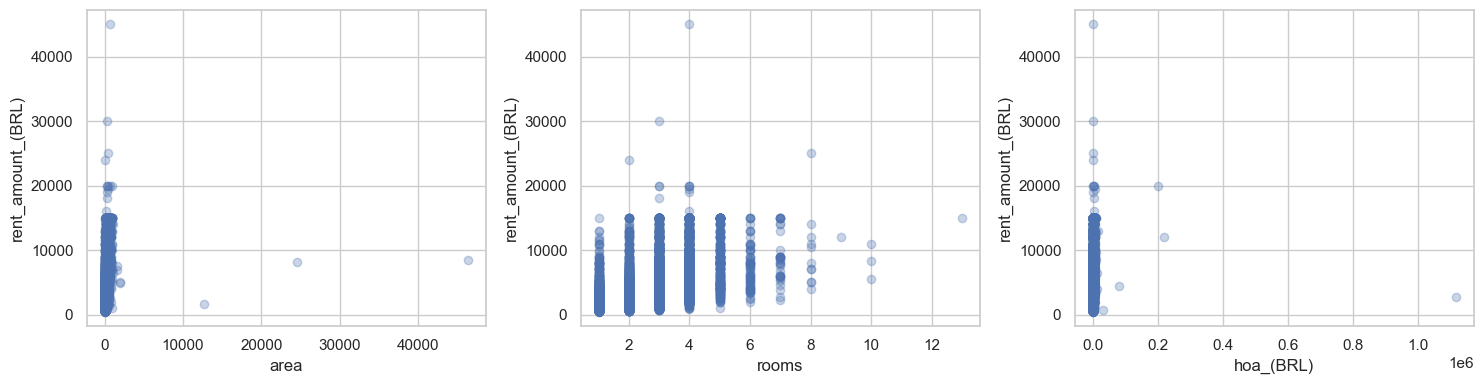

In [7]:
# ============================================================
# Примеры зависимостей признаков от таргета
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df["area"], df[target_col], alpha=0.3)
axes[0].set_xlabel("area")
axes[0].set_ylabel("rent_amount_(BRL)")

axes[1].scatter(df["rooms"], df[target_col], alpha=0.3)
axes[1].set_xlabel("rooms")
axes[1].set_ylabel("rent_amount_(BRL)")

axes[2].scatter(df["hoa_(BRL)"], df[target_col], alpha=0.3)
axes[2].set_xlabel("hoa_(BRL)")
axes[2].set_ylabel("rent_amount_(BRL)")

plt.tight_layout()
plt.show()


На графиках видно, что в целом с ростом площади и количества комнат аренда обычно становится выше: самые дешёвые объекты — маленькие и с 1–2 комнатами, а более дорогие — чаще крупнее и с большим числом комнат. При этом на всех трёх графиках есть немного точек очень далеко от основной массы — это редкие объекты с очень большой площадью, высокой арендой или крупными доплатами, которые выглядят как явные выбросы и могут сильно влиять на модели.

---

## Метрики и логирование результатов

В этом блоке:

- определим метрики для регрессии;
- создадим словарь `results`;
- напишем функции `log_results` и `print_metrics`, которыми будем пользоваться
  во всех последующих моделях.

Будем считать:

- **MSE (Mean Squared Error)** — средняя квадратичная ошибка, удобна как «техническая» метрика и сильно штрафует большие промахи модели.
- **RMSE (Root MSE)** — корень из MSE, показывает типичный размер ошибки в тех же единицах, что и таргет (проще интерпретировать в деньгах).
- **MAE (Mean Absolute Error)** — средняя абсолютная ошибка, даёт «среднюю ошибку» без усиленного штрафа за выбросы и более устойчива к редким экстремальным значениям.
- **R2 (coefficient of determination)** — доля объяснённой вариации таргета, показывает, насколько модель лучше тривиального предсказания среднего (чем ближе к 1, тем лучше).


In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}

def log_results(model_name: str, split: str, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    if model_name not in results:
        results[model_name] = {}

    results[model_name][split] = {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }

def print_metrics(split_name: str, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"=== {split_name} ===")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"R2  : {r2:.4f}")
    print()


---

## Бейзлайн: предсказываем среднюю аренду

Здесь построим бейзлайн-модель, которая **для любого объекта просто предсказывает
среднее значение аренды на обучающей выборке**. Такая модель не использует
вообще никаких признаков, и служит точкой сравнения: любая адекватная модель
должна работать не хуже этого бейзлайна.


In [9]:
# ============================================================
# Бейзлайн: предсказываем среднюю аренду по train
# ============================================================

baseline_name = "Baseline: mean(rent)"

# средняя аренда только по train
y_train_mean = y_train.mean()
print(f"Средняя аренда на train: {y_train_mean:.2f} BRL")

# предсказания: одно и то же число для всех объектов
y_train_pred = np.full_like(y_train, fill_value=y_train_mean, dtype=float)
y_val_pred   = np.full_like(y_val,   fill_value=y_train_mean, dtype=float)
y_test_pred  = np.full_like(y_test,  fill_value=y_train_mean, dtype=float)

# логируем результаты
log_results(baseline_name, "train", y_train, y_train_pred)
log_results(baseline_name, "val",   y_val,   y_val_pred)
log_results(baseline_name, "test",  y_test,  y_test_pred)

# печатаем метрики
print("Модель:", baseline_name)
print_metrics("Train", y_train, y_train_pred)
print_metrics("Val",   y_val,   y_val_pred)
print_metrics("Test",  y_test,  y_test_pred)


Средняя аренда на train: 3982.66 BRL
Модель: Baseline: mean(rent)
=== Train ===
MSE : 11771193.33
RMSE: 3430.92
MAE : 2567.14
R2  : 0.0000

=== Val ===
MSE : 12342515.39
RMSE: 3513.19
MAE : 2640.21
R2  : -0.0003

=== Test ===
MSE : 11675775.12
RMSE: 3416.98
MAE : 2541.58
R2  : -0.0003



---

## Линейная регрессия

Построим **линейную регрессию**.

В этом блоке:

- масштабируем признаки с помощью `StandardScaler`;
- обучим `LinearRegression` на train;
- посчитаем метрики на `train / val / test`;
- сравним результаты с бейзлайном.

Масштабирование нужно, чтобы все признаки были в сопоставимых единицах и веса модели
корректно интерпретировались, особенно при дальнейшем добавлении регуляризации.


In [10]:
# ============================================================
# Линейная регрессия с масштабированием признаков
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

set_seed(111)

linreg_name = "Linear Regression"

linreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# обучение на train
linreg_pipeline.fit(X_train, y_train)

# предсказания
y_train_pred = linreg_pipeline.predict(X_train)
y_val_pred   = linreg_pipeline.predict(X_val)
y_test_pred  = linreg_pipeline.predict(X_test)

# логируем результаты
log_results(linreg_name, "train", y_train, y_train_pred)
log_results(linreg_name, "val",   y_val,   y_val_pred)
log_results(linreg_name, "test",  y_test,  y_test_pred)

print("Модель:", linreg_name)
print_metrics("Train", y_train, y_train_pred)
print_metrics("Val",   y_val,   y_val_pred)
print_metrics("Test",  y_test,  y_test_pred)


Модель: Linear Regression
=== Train ===
MSE : 269177.90
RMSE: 518.82
MAE : 334.59
R2  : 0.9771

=== Val ===
MSE : 436964.27
RMSE: 661.03
MAE : 348.84
R2  : 0.9646

=== Test ===
MSE : 774502.65
RMSE: 880.06
MAE : 358.45
R2  : 0.9336



Линейная регрессия заметно улучшает качество по сравнению с бейзлайном: ошибки RMSE и MAE на всех выборках стали в разы меньше (около 500–900 BRL и 330–360 BRL соответственно), а R² на валидации и тесте достигает ≈0.96 и ≈0.93. Поскольку для ошибок (MSE/RMSE/MAE) мы стремимся к нулю, а для R² — к единице, такие значения означают, что модель уже хорошо приближает реальные арендные ставки и объясняет большую часть их разброса. При этом качество на train чуть лучше, чем на val/test, что говорит о лёгком, но пока приемлемом переобучении.

---

## Ridge-регрессия (L2-регуляризация)

In [13]:
# ============================================================
# Ridge-регрессия (L2-регуляризация)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

# фиксируем seed в модельном блоке
set_seed(111)

ridge_name = "Ridge "

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=5.0))
])

# обучение на train
ridge_pipeline.fit(X_train, y_train)

# предсказания
y_train_pred = ridge_pipeline.predict(X_train)
y_val_pred   = ridge_pipeline.predict(X_val)
y_test_pred  = ridge_pipeline.predict(X_test)

# логируем результаты
log_results(ridge_name, "train", y_train, y_train_pred)
log_results(ridge_name, "val",   y_val,   y_val_pred)
log_results(ridge_name, "test",  y_test,  y_test_pred)

print("Модель:", ridge_name)
print_metrics("Train", y_train, y_train_pred)
print_metrics("Val",   y_val,   y_val_pred)
print_metrics("Test",  y_test,  y_test_pred)


Модель: Ridge 
=== Train ===
MSE : 269194.47
RMSE: 518.84
MAE : 334.81
R2  : 0.9771

=== Val ===
MSE : 434836.13
RMSE: 659.42
MAE : 348.99
R2  : 0.9648

=== Test ===
MSE : 784220.93
RMSE: 885.56
MAE : 358.81
R2  : 0.9328



При увеличении параметра alpha в Ridge-регрессии качество на валидации не улучшается, 
а наоборот постепенно падает: модель начинает сильнее зажимать веса, становится слишком простой и теряет полезную информацию. 
В нашем датасете и без сильной регуляризации линейная регрессия обобщает достаточно хорошо, поэтому дополнительное усиление штрафа только повышает ошибки и снижает R².

---

## Lasso-регрессия (L1-регуляризация)

Теперь попробуем Lasso — линейную регрессию с **L1-регуляризацией**.

- **L2 (Ridge)** сглаживает веса, делая их поменьше, но почти не обнуляет;
- **L1 (Lasso)** может не только уменьшать веса, но и **обнулять** их, по сути автоматически
  выбирая более важные признаки и отбрасывая менее полезные.


In [17]:
# ============================================================
# Lasso-регрессия (L1-регуляризация)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso

# фиксируем seed в модельном блоке
set_seed(111)

lasso_name = "Lasso "

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=100, max_iter=10000))
])

# обучение на train
lasso_pipeline.fit(X_train, y_train)

# предсказания
y_train_pred = lasso_pipeline.predict(X_train)
y_val_pred   = lasso_pipeline.predict(X_val)
y_test_pred  = lasso_pipeline.predict(X_test)

# логируем результаты
log_results(lasso_name, "train", y_train, y_train_pred)
log_results(lasso_name, "val",   y_val,   y_val_pred)
log_results(lasso_name, "test",  y_test,  y_test_pred)

print("Модель:", lasso_name)
print_metrics("Train", y_train, y_train_pred)
print_metrics("Val",   y_val,   y_val_pred)
print_metrics("Test",  y_test,  y_test_pred)


Модель: Lasso 
=== Train ===
MSE : 297421.92
RMSE: 545.36
MAE : 364.84
R2  : 0.9747

=== Val ===
MSE : 359861.58
RMSE: 599.88
MAE : 376.29
R2  : 0.9708

=== Test ===
MSE : 316788.74
RMSE: 562.84
MAE : 367.95
R2  : 0.9729



In [18]:
# ============================================================
# Демонстрация: влияние alpha в Lasso
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]

rows = []

for a in alphas:
    set_seed(111)
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=a, max_iter=10000))
    ])
    
    pipe.fit(X_train, y_train)
    
    y_train_pred = pipe.predict(X_train)
    y_val_pred   = pipe.predict(X_val)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, y_train_pred)
    
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, y_val_pred)
    
    rows.append({
        "alpha": a,
        "train_RMSE": train_rmse,
        "train_R2": train_r2,
        "val_RMSE": val_rmse,
        "val_R2": val_r2,
    })

lasso_alpha_df = pd.DataFrame(rows)
lasso_alpha_df.sort_values("val_RMSE")


,alpha,train_RMSE,train_R2,val_RMSE,val_R2
5,100.000,545.364024,0.974733,599.884636,0.970836
4,10.000,520.300225,0.977002,628.434909,0.967994
3,1.000,518.837385,0.977131,657.573428,0.964957
2,0.100,518.823731,0.977132,660.637185,0.964630
1,0.010,518.823579,0.977132,660.996147,0.964592
0,0.001,518.823578,0.977132,661.029484,0.964588
6,500.000,733.090662,0.954344,807.062986,0.947213
7,1000.000,1134.646164,0.890629,1212.338168,0.880888


##  Elastic Net (L1 + L2 регуляризация)

Elastic Net — это линейная модель, которая одновременно использует и L1-, и L2-регуляризацию:


In [19]:
# ============================================================
# Elastic Net (L1 + L2 регуляризация)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet

# фиксируем seed в модельном блоке
set_seed(111)

enet_name = "ElasticNet (alpha=0.1, l1_ratio=0.5)"

enet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000))
])

# обучение на train
enet_pipeline.fit(X_train, y_train)

# предсказания
y_train_pred = enet_pipeline.predict(X_train)
y_val_pred   = enet_pipeline.predict(X_val)
y_test_pred  = enet_pipeline.predict(X_test)

# логируем результаты
log_results(enet_name, "train", y_train, y_train_pred)
log_results(enet_name, "val",   y_val,   y_val_pred)
log_results(enet_name, "test",  y_test,  y_test_pred)

print("Модель:", enet_name)
print_metrics("Train", y_train, y_train_pred)
print_metrics("Val",   y_val,   y_val_pred)
print_metrics("Test",  y_test,  y_test_pred)


Модель: ElasticNet (alpha=0.1, l1_ratio=0.5)
=== Train ===
MSE : 318625.15
RMSE: 564.47
MAE : 376.34
R2  : 0.9729

=== Val ===
MSE : 406637.87
RMSE: 637.68
MAE : 389.80
R2  : 0.9670

=== Test ===
MSE : 1543031.56
RMSE: 1242.19
MAE : 404.74
R2  : 0.8678



Для ElasticNet при выбранных параметрах регуляризации качество на train и val остаётся высоким, но на тестовой выборке заметно падает (RMSE растёт до ~1240 BRL, R² падает до ~0.87). Это показывает, что текущая настройка alpha и l1_ratio делает модель слишком жёсткой: она хуже подстраивается под некоторые объекты из теста (особенно «экстремальные» по аренде), поэтому в реальности такая модель может обобщать хуже, чем обычная линейная регрессия.

---

## Полиномиальные признаки + Ridge

До этого мы использовали только исходные признаки в линейной модели.  
Теперь попробуем добавить **полиномиальные признаки степени 2**: квадраты
и попарные произведения признаков. Такая модель всё ещё линейна по весам,
но может приближать более сложные (нелинейные) зависимости.

В этом блоке:

- сгенерируем полиномиальные признаки степени 2;
- отмасштабируем расширенный набор признаков;
- обучим на нём `Ridge`, чтобы не переобучиться из-за роста числа фич;


In [23]:
# ============================================================
# Полиномиальные признаки (degree=2) + Ridge
# ============================================================

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso

set_seed(111)

poly_ridge_name = "Poly(degree=2) + Ridge(alpha=1.0)"

poly_ridge_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=100.0))
])

# обучение на train
poly_ridge_pipeline.fit(X_train, y_train)

# предсказания
y_train_pred = poly_ridge_pipeline.predict(X_train)
y_val_pred   = poly_ridge_pipeline.predict(X_val)
y_test_pred  = poly_ridge_pipeline.predict(X_test)

# логируем результаты
log_results(poly_ridge_name, "train", y_train, y_train_pred)
log_results(poly_ridge_name, "val",   y_val,   y_val_pred)
log_results(poly_ridge_name, "test",  y_test,  y_test_pred)

print("Модель:", poly_ridge_name)
print_metrics("Train", y_train, y_train_pred)
print_metrics("Val",   y_val,   y_val_pred)
print_metrics("Test",  y_test,  y_test_pred)


Модель: Poly(degree=2) + Ridge(alpha=1.0)
=== Train ===
MSE : 292111.16
RMSE: 540.47
MAE : 361.61
R2  : 0.9752

=== Val ===
MSE : 355571.74
RMSE: 596.30
MAE : 373.53
R2  : 0.9712

=== Test ===
MSE : 312399.00
RMSE: 558.93
MAE : 365.27
R2  : 0.9732



Добавление полиномиальных признаков степени 2 резко усложнило модель: на обучении она почти идеально подгоняет данные (R² ≈ 0.99), но на тесте качество падает до R² ≈ –18. Это пример сильного переобучения и неустойчивой экстраполяции: комбинация квадратов и произведений признаков, особенно для больших значений площади и денежных колонок, приводит к очень нестабильному поведению модели на новых объектах. По сравнению с простой линейной регрессией такая полиномиальная модель здесь явно проигрывает и в реальной задаче так использовать её нельзя.

---

## Дерево решений для регрессии

- дерево само умеет моделировать **нелинейности** и взаимодействия признаков;
- не требует масштабирования признаков;
- при слишком большой глубине легко **переобучается**.



In [26]:
# ============================================================
# Дерево решений для регрессии
# ============================================================

from sklearn.tree import DecisionTreeRegressor

set_seed(111)

tree_name = "Decision Tree"

tree_model = DecisionTreeRegressor(
    max_depth=7,
    random_state=111
)

# обучение на train
tree_model.fit(X_train, y_train)

# предсказания
y_train_pred = tree_model.predict(X_train)
y_val_pred   = tree_model.predict(X_val)
y_test_pred  = tree_model.predict(X_test)

# логируем результаты
log_results(tree_name, "train", y_train, y_train_pred)
log_results(tree_name, "val",   y_val,   y_val_pred)
log_results(tree_name, "test",  y_test,  y_test_pred)

print("Модель:", tree_name)
print_metrics("Train", y_train, y_train_pred)
print_metrics("Val",   y_val,   y_val_pred)
print_metrics("Test",  y_test,  y_test_pred)


Модель: Decision Tree
=== Train ===
MSE : 75143.68
RMSE: 274.12
MAE : 135.85
R2  : 0.9936

=== Val ===
MSE : 206627.48
RMSE: 454.56
MAE : 161.78
R2  : 0.9833

=== Test ===
MSE : 147090.54
RMSE: 383.52
MAE : 160.04
R2  : 0.9874



Дерево решений уже при небольшой глубине max_depth = 5 даёт качество лучше линейной регрессии: RMSE на тесте снижается до ≈ 620 BRL, а R² растёт до ≈ 0.97. Увеличение глубины до max_depth = 7 ещё сильнее улучшает качество (RMSE на тесте ≈ 380 BRL, R² ≈ 0.99): модель лучше ловит нелинейные зависимости и взаимодействия признаков. При этом разрыв между train и val/test есть, но не выглядит критичным, так что на этих значениях глубины деревья обобщают даже лучше, чем линейные модели.

---

## Случайный лес (Random Forest)

Случайный лес — это ансамбль из многих деревьев решений, обученных на разных
подвыборках данных и наборов признаков. За счёт усреднения предсказаний

In [27]:
# ============================================================
# Случайный лес для регрессии
# ============================================================

from sklearn.ensemble import RandomForestRegressor

set_seed(111)

rf_name = "Random Forest (n=200, max_depth=10)"

rf_model = RandomForestRegressor(
    n_estimators=200,   # количество деревьев в лесе
    max_depth=10,       # максимальная глубина каждого дерева
    random_state=111,
    n_jobs=-1           # используем все доступные ядра
)

# обучение на train
rf_model.fit(X_train, y_train)

# предсказания
y_train_pred = rf_model.predict(X_train)
y_val_pred   = rf_model.predict(X_val)
y_test_pred  = rf_model.predict(X_test)

# логируем результаты
log_results(rf_name, "train", y_train, y_train_pred)
log_results(rf_name, "val",   y_val,   y_val_pred)
log_results(rf_name, "test",  y_test,  y_test_pred)

print("Модель:", rf_name)
print_metrics("Train", y_train, y_train_pred)
print_metrics("Val",   y_val,   y_val_pred)
print_metrics("Test",  y_test,  y_test_pred)


Модель: Random Forest (n=200, max_depth=10)
=== Train ===
MSE : 38300.81
RMSE: 195.71
MAE : 81.20
R2  : 0.9967

=== Val ===
MSE : 180362.58
RMSE: 424.69
MAE : 139.47
R2  : 0.9854

=== Test ===
MSE : 120576.64
RMSE: 347.24
MAE : 138.43
R2  : 0.9897



По сравнению с одиночным деревом случайный лес даёт ещё немного лучшую обобщающую способность: RMSE на тесте снижается примерно до 350 BRL, а R² растёт до 0.9897, то есть ансамбль из деревьев чуть лучше сглаживает шум и стабилизирует предсказания.

---

## Градиентный бустинг по деревьям

Градиентный бустинг строит ансамбль деревьев **последовательно**: каждое новое дерево
пытается исправить ошибки всех предыдущих.


In [28]:
# ============================================================
# Градиентный бустинг для регрессии
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor

set_seed(111)

gbr_name = "Gradient Boosting (n=300, depth=3, lr=0.05)"

gbr_model = GradientBoostingRegressor(
    n_estimators=300,      # число деревьев
    learning_rate=0.05,   # шаг обучения
    max_depth=3,          # глубина базовых деревьев
    random_state=111
)

# обучение на train
gbr_model.fit(X_train, y_train)

# предсказания
y_train_pred = gbr_model.predict(X_train)
y_val_pred   = gbr_model.predict(X_val)
y_test_pred  = gbr_model.predict(X_test)

# логируем результаты
log_results(gbr_name, "train", y_train, y_train_pred)
log_results(gbr_name, "val",   y_val,   y_val_pred)
log_results(gbr_name, "test",  y_test,  y_test_pred)

print("Модель:", gbr_name)
print_metrics("Train", y_train, y_train_pred)
print_metrics("Val",   y_val,   y_val_pred)
print_metrics("Test",  y_test,  y_test_pred)


Модель: Gradient Boosting (n=300, depth=3, lr=0.05)
=== Train ===
MSE : 66033.82
RMSE: 256.97
MAE : 130.84
R2  : 0.9944

=== Val ===
MSE : 161302.69
RMSE: 401.63
MAE : 153.58
R2  : 0.9869

=== Test ===
MSE : 133618.50
RMSE: 365.54
MAE : 153.56
R2  : 0.9886



Градиентный бустинг тоже показывает очень высокое качество: ошибки на тесте (RMSE ≈ 366 BRL, MAE ≈ 154 BRL) остаются на уровне лучших моделей, а R² ≈ 0.9886 означает, что ансамбль объясняет почти весь разброс арендной ставки. По сравнению с линейными моделями он даёт заметный выигрыш, а по качеству находится примерно на одном уровне со случайным лесом.

---

## Support Vector Regression (SVR)

- использует ядра (например, RBF), чтобы моделировать **нелинейные зависимости**;
- работает с «опорными объектами» — не все точки влияют на решение;
- чувствителен к масштабу признаков и параметрам `C`, `gamma`, `epsilon`.

In [29]:
# ============================================================
# SVR (Support Vector Regression) с RBF-ядром
# ============================================================

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

set_seed(111)

svr_name = "SVR"

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf", C=100.0, epsilon=1))
])

# обучение на train
svr_pipeline.fit(X_train, y_train)

# предсказания
y_train_pred = svr_pipeline.predict(X_train)
y_val_pred   = svr_pipeline.predict(X_val)
y_test_pred  = svr_pipeline.predict(X_test)

# логируем результаты
log_results(svr_name, "train", y_train, y_train_pred)
log_results(svr_name, "val",   y_val,   y_val_pred)
log_results(svr_name, "test",  y_test,  y_test_pred)

print("Модель:", svr_name)
print_metrics("Train", y_train, y_train_pred)
print_metrics("Val",   y_val,   y_val_pred)
print_metrics("Test",  y_test,  y_test_pred)


Модель: SVR
=== Train ===
MSE : 943311.83
RMSE: 971.24
MAE : 348.64
R2  : 0.9199

=== Val ===
MSE : 740670.09
RMSE: 860.62
MAE : 355.36
R2  : 0.9400

=== Test ===
MSE : 783334.88
RMSE: 885.06
MAE : 347.18
R2  : 0.9329



---

## Простая нейросеть (MLPRegressor)



In [30]:
# ============================================================
# Простая нейросеть для регрессии (MLPRegressor)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor

set_seed(111)

mlp_name = "MLPRegressor (64,32)"

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),  # два скрытых слоя
        activation="relu",
        alpha=1e-4,                   # L2-регуляризация весов
        learning_rate_init=1e-3,
        max_iter=500,
        random_state=111
    ))
])

# обучение на train
mlp_pipeline.fit(X_train, y_train)

# предсказания
y_train_pred = mlp_pipeline.predict(X_train)
y_val_pred   = mlp_pipeline.predict(X_val)
y_test_pred  = mlp_pipeline.predict(X_test)

# логируем результаты
log_results(mlp_name, "train", y_train, y_train_pred)
log_results(mlp_name, "val",   y_val,   y_val_pred)
log_results(mlp_name, "test",  y_test,  y_test_pred)

print("Модель:", mlp_name)
print_metrics("Train", y_train, y_train_pred)
print_metrics("Val",   y_val,   y_val_pred)
print_metrics("Test",  y_test,  y_test_pred)


Модель: MLPRegressor (64,32)
=== Train ===
MSE : 171058.51
RMSE: 413.59
MAE : 228.00
R2  : 0.9855

=== Val ===
MSE : 223209.75
RMSE: 472.45
MAE : 237.94
R2  : 0.9819

=== Test ===
MSE : 202236.87
RMSE: 449.71
MAE : 236.87
R2  : 0.9827



c:\Prgrm\Intro_in_ML\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Простая нейросеть (MLPRegressor) показывает приличное качество (RMSE на тесте ≈ 450 BRL, R² ≈ 0.9827) и заметно лучше линейных моделей, но чуть уступает деревьям и их ансамблям. Обучение сопровождается предупреждением о нехватке итераций: оптимизатор не до конца сошёлся за 500 шагов, поэтому сеть выглядит скорее слегка недообученной. Для дальнейшего улучшения качества потребовался бы более тщательный подбор архитектуры и гиперпараметров (число слоёв, нейронов, alpha, max_iter, early_stopping и т.д.).

---

## Сводка результатов всех моделей

Соберём метрики из словаря `results` в одну таблицу и посмотрим,
кто как себя ведёт на train / val / test.


In [31]:
# ============================================================
# Сводная таблица по моделям: сплиты как колонки (pivot)
# ============================================================

rows = []

for model_name, splits in results.items():
    for split_name, metrics in splits.items():
        rows.append({
            "model": model_name,
            "split": split_name,
            "mse": metrics["mse"],
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
        })

results_df = pd.DataFrame(rows)

# pivot: модели в строках, сплиты в колонках, метрики — верхний уровень
wide_df = results_df.pivot(
    index="model",
    columns="split",
    values=["rmse", "mae", "r2"]
)


wide_df = wide_df.sort_values(("rmse", "test"))

wide_df


rmse               \
split                                               test        train   
model                                                                   
Random Forest (n=200, max_depth=10)           347.241476   195.705920   
Gradient Boosting (n=300, depth=3, lr=0.05)   365.538638   256.970463   
Decision Tree                                 383.523845   274.123481   
MLPRegressor (64,32)                          449.707539   413.592207   
Poly(degree=2) + Ridge(alpha=1.0)             558.926650   540.473086   
Lasso                                         562.839890   545.364024   
Linear Regression                             880.058320   518.823578   
SVR                                           885.062076   971.242415   
Ridge                                         885.562495   518.839543   
ElasticNet (alpha=0.1, l1_ratio=0.5)         1242.188213   564.468910   
Baseline: mean(rent)                         3416.983336  3430.917272   

                                                                  mae  \
split                                                val         test   
model                                                                   
Random Forest (n=200, max_depth=10)           424.691154   138.427218   
Gradient Boosting (n=300, depth=3, lr=0.05)   401.625056   153.561294   
Decision Tree                                 454.562951   160.038597   
MLPRegressor (64,32)                          472.450789   236.866196   
Poly(degree=2) + Ridge(alpha=1.0)             596.298364   365.272853   
Lasso                                         599.884636   367.954833   
Linear Regression                             661.032728   358.454832   
SVR                                           860.621920   347.182420   
Ridge                                         659.421057   358.811965   
ElasticNet (alpha=0.1, l1_ratio=0.5)          637.681633   404.742858   
Baseline: mean(rent)                         3513.191625  2541.578161   

                                                                       \
split                                              train          val   
model                                                                   
Random Forest (n=200, max_depth=10)            81.198470   139.471147   
Gradient Boosting (n=300, depth=3, lr=0.05)   130.844632   153.577657   
Decision Tree                                 135.854327   161.780532   
MLPRegressor (64,32)                          228.000667   237.942987   
Poly(degree=2) + Ridge(alpha=1.0)             361.610521   373.530243   
Lasso                                         364.842145   376.290741   
Linear Regression                             334.587033   348.836897   
SVR                                           348.637641   355.362804   
Ridge                                         334.810462   348.994071   
ElasticNet (alpha=0.1, l1_ratio=0.5)          376.339513   389.803372   
Baseline: mean(rent)                         2567.142380  2640.212297   

                                                   r2                      
split                                            test     train       val  
model                                                                      
Random Forest (n=200, max_depth=10)          0.989670  0.996746  0.985383  
Gradient Boosting (n=300, depth=3, lr=0.05)  0.988553  0.994390  0.986928  
Decision Tree                                0.987399  0.993616  0.983255  
MLPRegressor (64,32)                         0.982674  0.985468  0.981911  
Poly(degree=2) + Ridge(alpha=1.0)            0.973236  0.975184  0.971184  
Lasso                                        0.972860  0.974733  0.970836  
Linear Regression                            0.933647  0.977132  0.964588  
SVR                                          0.932890  0.919863  0.939975  
Ridge                                        0.932815  0.977131  0.964760  
ElasticNet (alpha=0.1, l1_ratio=0.5)         0.867806  0.972932  0.9670

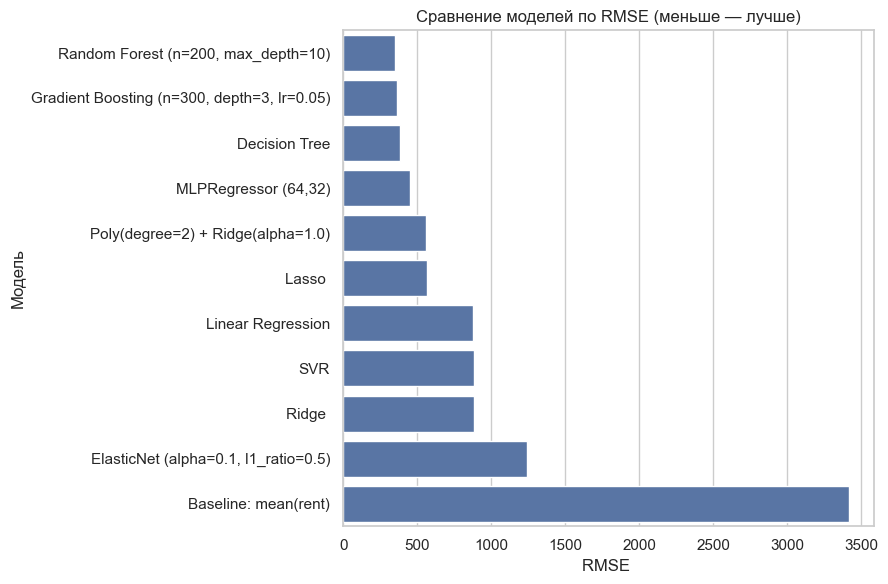

In [32]:

val_rmse = wide_df["rmse"]["test"].sort_values()

plt.figure(figsize=(9, 6))
sns.barplot(x=val_rmse.values, y=val_rmse.index)
plt.xlabel("RMSE ")
plt.ylabel("Модель")
plt.title("Сравнение моделей по RMSE (меньше — лучше)")
plt.tight_layout()
plt.show()


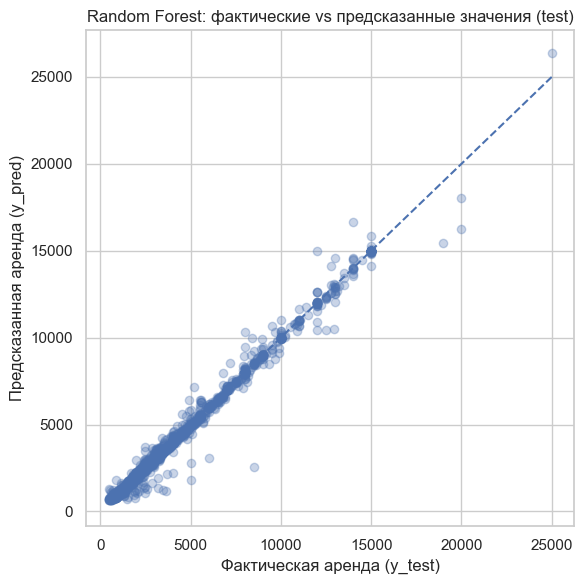

In [33]:
# ============================================================
# y_true vs y_pred для RF
# ============================================================

y_test_pred_rf = rf_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Фактическая аренда (y_test)")
plt.ylabel("Предсказанная аренда (y_pred)")
plt.title("Random Forest: фактические vs предсказанные значения (test)")
plt.tight_layout()
plt.show()


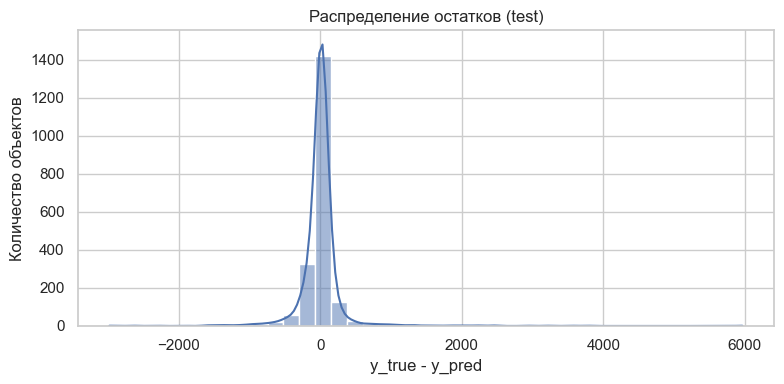

In [34]:
# ============================================================
# Остатки для Random Forest
# ============================================================

residuals = y_test - y_test_pred_rf

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Распределение остатков (test)")
plt.xlabel("y_true - y_pred")
plt.ylabel("Количество объектов")
plt.tight_layout()
plt.show()


На гистограмме остатков видно, что основная масса ошибок сосредоточена в узкой зоне вокруг нуля (примерно в диапазоне ±500–700 BRL), распределение выглядит довольно симметричным. Это значит, что модель в среднем не завышает и не занижает цену аренды и обычно ошибается не очень сильно.

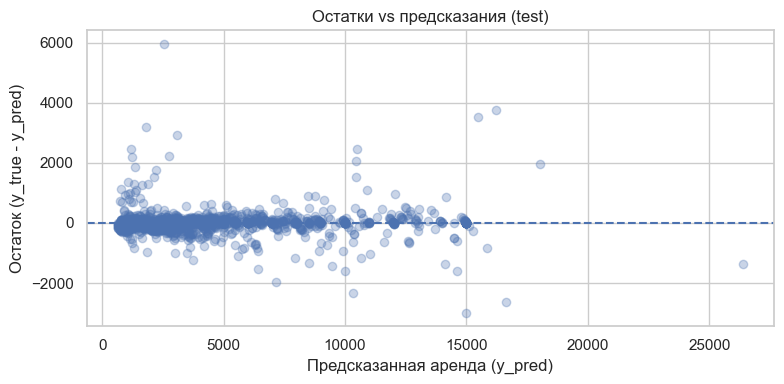

In [35]:
plt.figure(figsize=(8, 4))
plt.scatter(y_test_pred_rf, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Предсказанная аренда (y_pred)")
plt.ylabel("Остаток (y_true - y_pred)")
plt.title("Остатки vs предсказания (test)")
plt.tight_layout()
plt.show()


На графике «остатки vs предсказания» точки в основном хаотично лежат вокруг горизонтальной линии 0, без явного тренда — то есть систематического смещения почти нет. При этом для более дорогих объектов разброс остатков становится больше, а среди самых высоких предсказаний заметны крупные отрицательные остатки, что говорит о том, что для очень дорогих квартир модель иногда переоценивает аренду и даёт большие промахи. В целом же картинка типичная для адекватной модели: большинство ошибок небольшие и случайные, а сильные промахи — редкие выбросы.